# TP2 – Etapa 3 en Google Colab: Pipeline de Detección y Clasificación

Notebook de informe de la Etapa 3: detección de objetos con YOLOv8 y clasificación
de raza mediante el modelo fine-tuned en la Etapa 2.

El pipeline exporta y reutiliza directamente las funciones `detect_dogs` y `classify_detected_dog`
del servicio `DetectionService` del backend. Se documenta el flujo completo paso por paso
y se valida el funcionamiento del sistema bajo los tres escenarios exigidos por la consigna:

1. **Un perro** (`data/demo/single.jpg`)
2. **Múltiples perros** (`data/demo/multi.jpg`)
3. **Escenas complejas con otros objetos** (`data/demo/complex.jpg`)

## Equipo
- Juan Andres Morales
- Genaro Canciani

## 1. Configuración del entorno

Se desactiva pgvector (exclusivo de la base vectorial en la Etapa 1) y se añade `src/`
al path de Python para poder importar los servicios del backend sin duplicar código.

> **Importante:** Verificá que el entorno virtual del proyecto (`.venv`) esté activado
> en tu IDE o en Colab.

In [31]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings
from lib.bootstrap import build_classifier, build_detection

import torch
print("=" * 55)
print("ENTORNO DE EJECUCIÓN")
print("=" * 55)
print(f"  PyTorch versión : {torch.__version__}")
print(f"  Aceleración GPU : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"  Dispositivo     : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"  Carpeta data    : {settings.data_path}")
print(f"  Modelo YOLO     : {settings.yolo_model}")
print(f"  Umbral conf.    : {settings.yolo_conf_threshold}")
print(f"  COCO Dog ID     : {settings.yolo_dog_class_id}")

ENTORNO DE EJECUCIÓN
  PyTorch versión : 2.11.0+cu130
  Aceleración GPU : False (CPU)
  Dispositivo     : cpu
  Carpeta data    : data
  Modelo YOLO     : yolov8n.pt
  Umbral conf.    : 0.25
  COCO Dog ID     : 16


## 2. Construcción e instanciación de los servicios

Se instancian `ClassifierService` y `DetectionService` mediante el módulo `bootstrap`.
Al utilizar el mismo factory que el servidor FastAPI, garantizamos paridad absoluta
de lógica e hiperparámetros entre este informe y el backend web.

In [32]:
classifier = build_classifier(settings)
detector = build_detection(settings, classifier)

print("Servicio de Clasificación configurado:")
print(f"  - Modelo activo : {classifier.active_model_name}")
print(f"  - Checkpoint    : {classifier.active_checkpoint}")
print(f"  - Resolución    : {classifier.image_size}x{classifier.image_size}px")
print()
print("Servicio de Detección configurado:")
print(f"  - Detector YOLO : {detector.yolo_model_name}")
print(f"  - Confianza min : {detector.conf_threshold}")
print(f"  - Clase objetivo: {detector.dog_class_id} ('dog')")

Servicio de Clasificación configurado:
  - Modelo activo : resnet18_finetuned
  - Checkpoint    : models/resnet18_finetuned.pth
  - Resolución    : 224x224px

Servicio de Detección configurado:
  - Detector YOLO : yolov8n.pt
  - Confianza min : 0.25
  - Clase objetivo: 16 ('dog')


## 3. Caso 1: Un perro — Flujo paso a paso

Para documentar internamente cómo transforma los datos el pipeline, ejecutaremos
fase por fase el procesamiento sobre la imagen `data/demo/single.jpg`.

### Paso 1: Carga de la imagen
Cargamos la imagen original en formato BGR con OpenCV y convertimos a RGB para visualizar.

Imagen seleccionada (Caso 1): data/demo/single.jpg


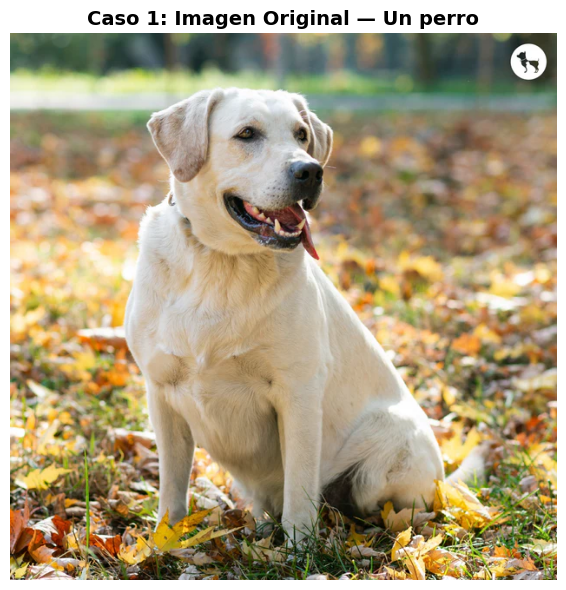

Resolución original: 630x630px


In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Definimos el path a la imagen del Caso 1
demo_dir = settings.data_path / "demo"
single_img_path = demo_dir / "single.jpg"

# Fallback amigable por si la ejecutan en un entorno limpio sin carpeta demo
if not single_img_path.exists():
    print(f"⚠️ Aviso: No se encontró {single_img_path}, usando imagen de test temporal...")
    single_img_path = list((settings.dataset_path / "test" / "Golden Retriever").glob("*.jpg"))[0]

IMAGE_PATH_1 = str(single_img_path)
print(f"Imagen seleccionada (Caso 1): {IMAGE_PATH_1}")

image_bgr_1 = cv2.imread(IMAGE_PATH_1)
if image_bgr_1 is None:
    raise ValueError(f"No se pudo leer la imagen: {IMAGE_PATH_1}")
image_rgb_1 = cv2.cvtColor(image_bgr_1, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(image_rgb_1)
ax.set_title("Caso 1: Imagen Original — Un perro", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Resolución original: {image_bgr_1.shape[1]}x{image_bgr_1.shape[0]}px")

### Paso 2: Detección de objetos con YOLO (`detect_dogs`)

Ejecutamos el detector pre-entrenado YOLOv8n. La función exportada `detect_dogs`
filtra automáticamente todas las cajas cuya clase predicha coincida con `yolo_dog_class_id` (`16`).

```python
def detect_dogs(self, image: np.ndarray) -> list[tuple[tuple[int, int, int, int], float]]:
    if self._yolo is None:
        self._yolo = YOLO(self.yolo_model_name)
    results = self._yolo(image, conf=self.conf_threshold, verbose=False)[0]
    detections = []
    if results.boxes is not None:
        for box, cls_id, conf in zip(results.boxes.xyxy, results.boxes.cls, results.boxes.conf):
            if int(cls_id) == self.dog_class_id:
                x1, y1, x2, y2 = map(int, box.tolist())
                detections.append(((x1, y1, x2, y2), float(conf)))
    return detections
```

In [34]:
detections_1 = detector.detect_dogs(image_bgr_1)

print(f"Detecciones positivas de perros: {len(detections_1)}")
print()
for i, (bbox, conf) in enumerate(detections_1):
    x1, y1, x2, y2 = bbox
    print(f"  [Detección #{i+1}]")
    print(f"    - Bounding Box : ({x1}, {y1}) → ({x2}, {y2})")
    print(f"    - Conf. YOLO   : {conf:.4f}")
    print(f"    - Dimensiones  : {x2-x1}x{y2-y1}px")
    print()

Detecciones positivas de perros: 1

  [Detección #1]
    - Bounding Box : (127, 49) → (509, 593)
    - Conf. YOLO   : 0.7886
    - Dimensiones  : 382x544px



### Paso 3: Generación de bounding boxes

Renderizamos las coordenadas `(x1, y1, x2, y2)` obtenidas sobre el lienzo original,
anotando el score de confianza del detector de objetos.

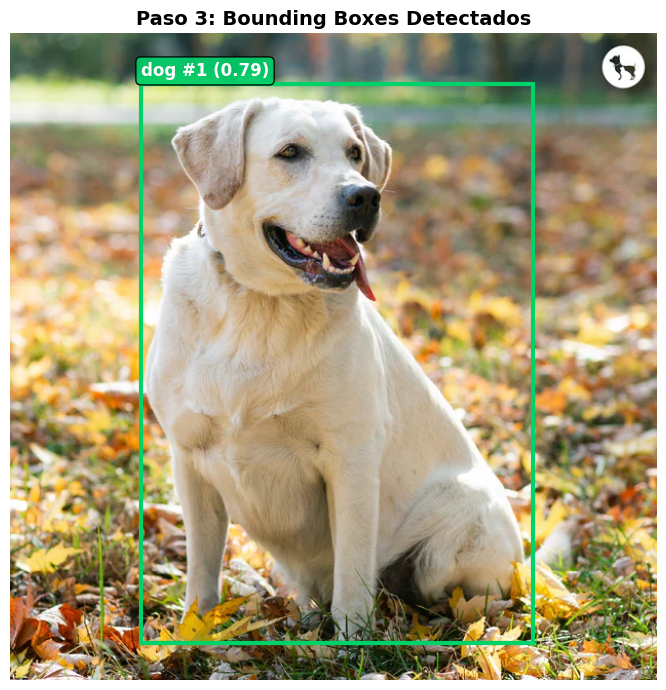

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.imshow(image_rgb_1)

for i, (bbox, conf) in enumerate(detections_1):
    x1, y1, x2, y2 = bbox
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                      linewidth=3, edgecolor="#00d26a", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(0, y1 - 8), f"dog #{i+1} ({conf:.2f})",
            color="white", fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#00d26a", alpha=0.9))

ax.set_title("Paso 3: Bounding Boxes Detectados", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

### Paso 4: Recorte de regiones detectadas (Crops)

Extraemos las matrices de píxeles correspondientes a cada caja delimitadora.
El método interno `_clip_xyxy` previene desbordamientos de índices.

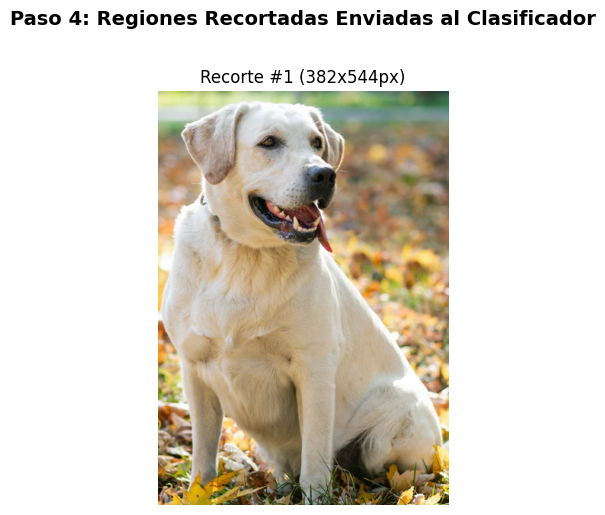

In [36]:
height_1, width_1 = image_bgr_1.shape[:2]
crops_1 = []

for i, (bbox, conf) in enumerate(detections_1):
    x1, y1, x2, y2 = bbox
    x1, y1, x2, y2 = detector._clip_xyxy(x1, y1, x2, y2, height_1, width_1)
    crop = image_bgr_1[y1:y2, x1:x2]
    crops_1.append((crop, bbox, conf))

if crops_1:
    fig, axes = plt.subplots(1, len(crops_1), figsize=(5 * len(crops_1), 5))
    if len(crops_1) == 1:
        axes = [axes]
    for i, (crop, bbox, conf) in enumerate(crops_1):
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        axes[i].imshow(crop_rgb)
        axes[i].set_title(f"Recorte #{i+1} ({crop.shape[1]}x{crop.shape[0]}px)", fontsize=12)
        axes[i].axis("off")
    plt.suptitle("Paso 4: Regiones Recortadas Enviadas al Clasificador", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### Paso 5: Clasificación de raza (`classify_detected_dog`)

Cada recorte ingresa a la red neuronal convolucional entrenada en la Etapa 2.
La función `classify_detected_dog` aplica el pipeline de preprocesamiento
(`Resize(224)`, normalización ImageNet) y evalúa probabilidades mediante Softmax.

```python
def classify_detected_dog(self, crop: np.ndarray) -> tuple[str, float]:
    # 1. Resuelve nombres de clases en data/dataset/train
    # 2. Carga pesos del modelo activo (ResNet18 / CNN)
    # 3. Transforma tensor de entrada
    # 4. Inferencia con torch.no_grad() + Softmax
    return class_name, confidence_score
```

In [37]:
results_1 = []

for i, (crop, bbox, det_conf) in enumerate(crops_1):
    breed, breed_score = detector.classify_detected_dog(crop)
    results_1.append({
        "idx": i + 1,
        "bbox": bbox,
        "det_conf": det_conf,
        "breed": breed,
        "breed_score": breed_score,
    })
    print(f"Predicción para Recorte #{i+1}:")
    print(f"  → Raza predicha     : {breed}")
    print(f"  → Score Clasificador: {breed_score:.4f} ({breed_score*100:.1f}%)")
    print(f"  → Score Detector    : {det_conf:.4f}")
    print()

Predicción para Recorte #1:
  → Raza predicha     : Rhodesian
  → Score Clasificador: 0.2863 (28.6%)
  → Score Detector    : 0.7886



### Paso 6: Predicciones finales integradas

Superponemos sobre la imagen completa los tres elementos exigidos por la consigna:
**Bounding boxes**, **Raza predicha** y **Score de confianza**.

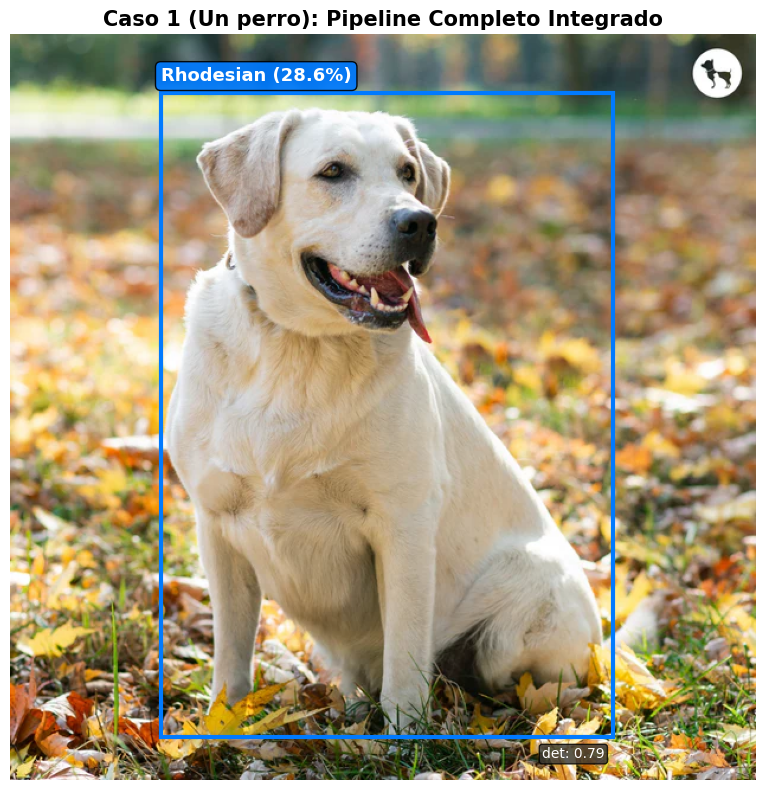

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(image_rgb_1)

for r in results_1:
    x1, y1, x2, y2 = r["bbox"]
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                      linewidth=3, edgecolor="#007aff", facecolor="none")
    ax.add_patch(rect)

    label_main = f"{r['breed']} ({r['breed_score']*100:.1f}%)"
    ax.text(x1, max(0, y1 - 10), label_main,
            color="white", fontsize=13, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#007aff", alpha=0.92))

    label_yolo = f"det: {r['det_conf']:.2f}"
    ax.text(x2 - 60, y2 + 18, label_yolo,
            color="white", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#333333", alpha=0.8))

ax.set_title("Caso 1 (Un perro): Pipeline Completo Integrado", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Orquestación automática del backend (`predict`)

El método `predict()` de `DetectionService` encapsula los 6 pasos anteriores
y genera automáticamente el payload JSON serializado que consume la interfaz web.

In [39]:
import json

out_dir = settings.output_path / "etapa3_demo"
json_path = detector.predict(IMAGE_PATH_1, out_dir)

with open(json_path, encoding='utf-8') as f:
    payload_json = json.load(f)

print("Objeto JSON generado por predict():")
print(json.dumps(payload_json, indent=2, ensure_ascii=False))

Objeto JSON generado por predict():
{
  "type": "detect",
  "source_path": "data/demo/single.jpg",
  "detections": [
    {
      "bbox": [
        127,
        49,
        509,
        593
      ],
      "det_score": 0.7886,
      "breed": "Rhodesian",
      "breed_score": 0.2863
    }
  ],
  "detected_breeds": [
    "Rhodesian"
  ]
}


## 5. Función auxiliar de visualización

Definimos una función compacta para inspeccionar rápidamente los siguientes dos casos
exigidos por la consigna reutilizando el mismo motor de inferencia.

In [40]:
def display_pipeline_case(img_path: Path, case_title: str):
    if not img_path.exists():
        print(f"⚠️ No se encontró {img_path}")
        return

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_bgr.shape[:2]

    dets = detector.detect_dogs(img_bgr)

    print("=" * 60)
    print(case_title.upper())
    print("=" * 60)
    print(f"Archivo       : {img_path}")
    print(f"Perros en YOLO: {len(dets)}")
    print()

    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    ax.imshow(img_rgb)

    colors = plt.cm.Dark2(np.linspace(0, 1, max(len(dets), 1)))

    for idx, (bbox, conf) in enumerate(dets):
        x1, y1, x2, y2 = bbox
        x1_c, y1_c, x2_c, y2_c = detector._clip_xyxy(x1, y1, x2, y2, h, w)
        crop = img_bgr[y1_c:y2_c, x1_c:x2_c]
        breed, score = detector.classify_detected_dog(crop)

        col = colors[idx % len(colors)]
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=3, edgecolor=col, facecolor="none")
        ax.add_patch(rect)

        lbl = f"#{idx+1} {breed} ({score*100:.1f}%)"
        ax.text(x1, max(0, y1 - 9), lbl, color="white", fontsize=12, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=col, alpha=0.92))

        print(f"  [Instancia #{idx+1}]")
        print(f"    - Raza predicha: {breed}")
        print(f"    - Confianza    : {score:.4f}")
        print(f"    - Bounding box : ({x1}, {y1}) → ({x2}, {y2}) [YOLO conf: {conf:.2f}]")
        print()

    ax.set_title(case_title, fontsize=15, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. Caso 2: Múltiples perros (`multi.jpg`)

Evaluamos el comportamiento del pipeline ante una escena que contiene múltiples
mascotas simultáneamente. YOLO separa cada instancia y el backend clasifica cada recorte.

CASO 2: DETECCIÓN Y CLASIFICACIÓN DE MÚLTIPLES PERROS
Archivo       : data/demo/multi.jpg
Perros en YOLO: 9

  [Instancia #1]
    - Raza predicha: Beagle
    - Confianza    : 0.4082
    - Bounding box : (942, 323) → (1115, 671) [YOLO conf: 0.94]

  [Instancia #2]
    - Raza predicha: Labrador
    - Confianza    : 0.8722
    - Bounding box : (566, 229) → (795, 666) [YOLO conf: 0.93]

  [Instancia #3]
    - Raza predicha: Greyhound
    - Confianza    : 0.3768
    - Bounding box : (808, 255) → (965, 664) [YOLO conf: 0.89]

  [Instancia #4]
    - Raza predicha: Great Dane
    - Confianza    : 0.6370
    - Bounding box : (57, 182) → (257, 656) [YOLO conf: 0.85]

  [Instancia #5]
    - Raza predicha: Greyhound
    - Confianza    : 0.2209
    - Bounding box : (434, 104) → (639, 632) [YOLO conf: 0.77]

  [Instancia #6]
    - Raza predicha: Chihuahua
    - Confianza    : 0.9430
    - Bounding box : (456, 455) → (560, 672) [YOLO conf: 0.75]

  [Instancia #7]
    - Raza predicha: French Bulldog
 

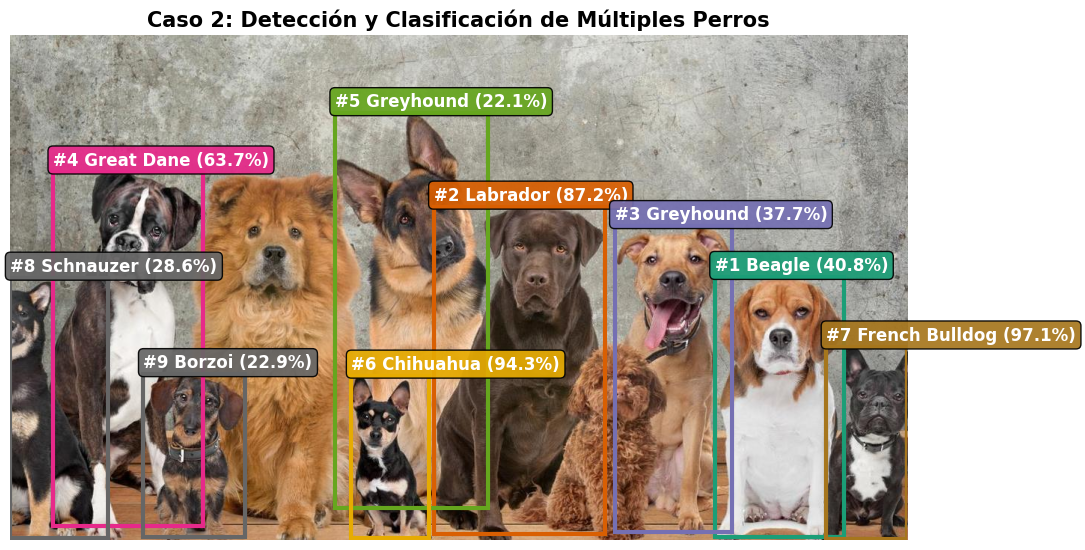

In [41]:
multi_img_path = demo_dir / "multi.jpg"
display_pipeline_case(multi_img_path, "Caso 2: Detección y Clasificación de Múltiples Perros")

## 7. Caso 3: Escenas complejas con otros objetos (`complex.jpg`)

Validamos la robustez del sistema en escenas complejas (por ejemplo: personas,
vehículos, muebles u otros animales en el fondo). Al estar acotado estrictamente
a la clase COCO `16` (*dog*), el detector ignora los objetos no pertinentes y
evita falsos positivos en el clasificador de razas.

CASO 3: ESCENA COMPLEJA (FILTRADO DE OBJETOS NO-PERRO)
Archivo       : data/demo/complex.jpg
Perros en YOLO: 5

  [Instancia #1]
    - Raza predicha: Beagle
    - Confianza    : 0.6370
    - Bounding box : (320, 529) → (484, 668) [YOLO conf: 0.76]

  [Instancia #2]
    - Raza predicha: Chinese Crested
    - Confianza    : 0.6060
    - Bounding box : (711, 468) → (825, 585) [YOLO conf: 0.75]

  [Instancia #3]
    - Raza predicha: Mex Hairless
    - Confianza    : 0.1785
    - Bounding box : (699, 480) → (750, 587) [YOLO conf: 0.70]

  [Instancia #4]
    - Raza predicha: Beagle
    - Confianza    : 0.3791
    - Bounding box : (270, 507) → (382, 661) [YOLO conf: 0.66]

  [Instancia #5]
    - Raza predicha: Siberian Husky
    - Confianza    : 0.1790
    - Bounding box : (117, 474) → (250, 615) [YOLO conf: 0.43]



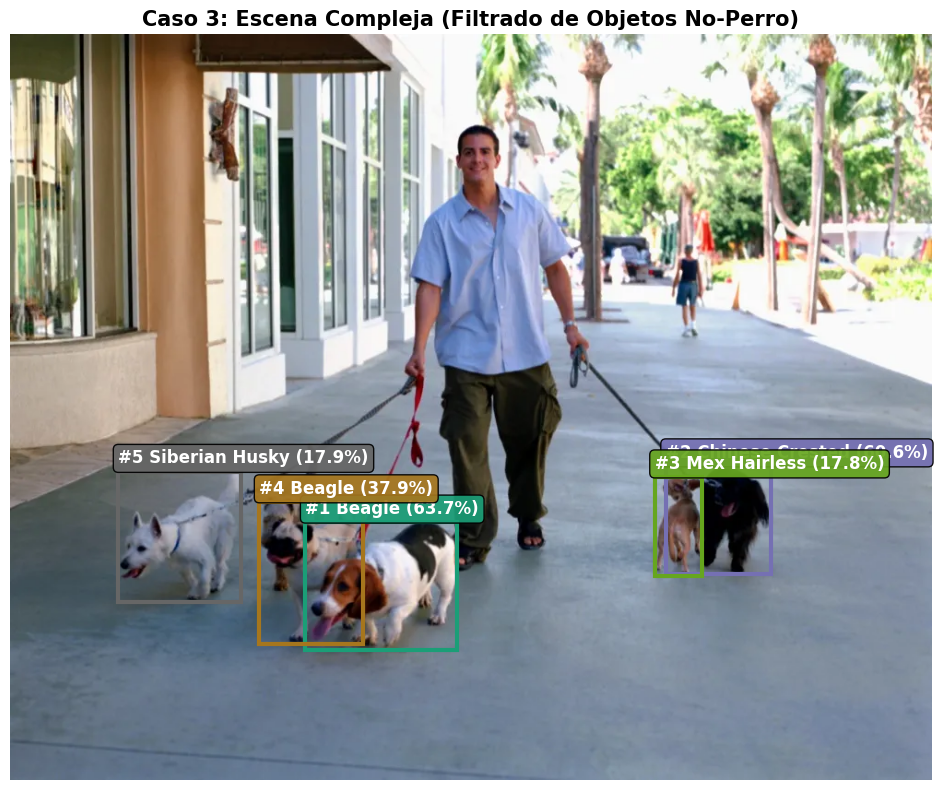

In [42]:
complex_img_path = demo_dir / "complex.jpg"
display_pipeline_case(complex_img_path, "Caso 3: Escena Compleja (Filtrado de Objetos No-Perro)")

## 8. Conclusiones de la Etapa 3

1. **Efectividad de la arquitectura en dos etapas:** El uso de un modelo detector generalista (YOLOv8)
   acoplado a un clasificador especialista (ResNet18 fine-tuned) permite resolver el problema
   sin necesidad de anotar bounding boxes de razas específicas.
2. **Resiliencia al ruido:** El filtrado por clase COCO elimina de raíz la necesidad de entrenar
   una clase *background* o de rechazo en el clasificador de razas.
3. **Paridad con producción:** El código ejecutado en este informe es exactamente el mismo
   que responde a las peticiones HTTP del frontend web.

### Resumen de APIs exportadas

| Función / Método | Módulo Origen | Responsabilidad |
| :--- | :--- | :--- |
| `detect_dogs(img)` | `lib.services.detection_service` | Retorna bounding boxes y scores YOLO de la clase perro |
| `classify_detected_dog(crop)` | `lib.services.detection_service` | Normaliza recorte e infiere raza y score con ResNet18 |
| `predict(path, out)` | `lib.services.detection_service` | Flujo end-to-end con serialización a JSON |